# IDRiD Diabetic Retinopathy — Stage 1: Data Preparation Pipeline

Yes. Below is the **Stage 1 implementation as separate Jupyter/Colab cells**, in order. Run **one cell at a time** and check the output before moving to the next.

This implements only:

**IDRiD → EDA → validation → train/validation split → preprocessing → augmentation → class weights → reusable PyTorch Dataset**

It does **not** train a model yet.

---

### Cell 1 — Install dependencies

In [1]:
# Cell 1: Install required packages

!pip install -q pandas numpy matplotlib seaborn pillow opencv-python scikit-learn imagehash

print("Dependencies installed")

Dependencies installed


### Cell 2 — Imports

In [2]:
# Cell 2: Imports

import os
import random
import json
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile

import cv2
import imagehash

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

warnings.filterwarnings("ignore")

ImageFile.LOAD_TRUNCATED_IMAGES = True

print("Libraries imported")
print("PyTorch:", torch.__version__)

Libraries imported
PyTorch: 2.4.1+cpu


### Cell 3 — Reproducibility

In [3]:
# Cell 3: Reproducibility

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Reproducibility settings
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed set to:", SEED)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Random seed set to: 42
CUDA available: False


### Cell 4 — Configure dataset path

Change only `DATASET_ROOT` if your ZIP/folder is somewhere else.

In [4]:
# Cell 4: Dataset configuration

# Example for Google Colab after extracting dataset.zip
DATASET_ROOT = Path(".")

# Expected structure:
# ./B. Disease Grading/

BASE_DIR = DATASET_ROOT / "B. Disease Grading"

TRAIN_IMAGE_DIR = BASE_DIR / "1. Original Images" / "a. Training Set"
TEST_IMAGE_DIR = BASE_DIR / "1. Original Images" / "b. Testing Set"

TRAIN_CSV = BASE_DIR / "2. Groundtruths" / "a. IDRiD_Disease Grading_Training Labels.csv"
TEST_CSV = BASE_DIR / "2. Groundtruths" / "b. IDRiD_Disease Grading_Testing Labels.csv"

OUTPUT_DIR = Path("./processed_idrid")

EDA_DIR = OUTPUT_DIR / "eda"
METADATA_DIR = OUTPUT_DIR / "metadata"
REPORT_DIR = OUTPUT_DIR / "reports"

for directory in [EDA_DIR, METADATA_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("TRAIN_IMAGE_DIR:", TRAIN_IMAGE_DIR)
print("TEST_IMAGE_DIR:", TEST_IMAGE_DIR)
print("TRAIN_CSV:", TRAIN_CSV)
print("TEST_CSV:", TEST_CSV)

BASE_DIR: B. Disease Grading
TRAIN_IMAGE_DIR: B. Disease Grading\1. Original Images\a. Training Set
TEST_IMAGE_DIR: B. Disease Grading\1. Original Images\b. Testing Set
TRAIN_CSV: B. Disease Grading\2. Groundtruths\a. IDRiD_Disease Grading_Training Labels.csv
TEST_CSV: B. Disease Grading\2. Groundtruths\b. IDRiD_Disease Grading_Testing Labels.csv


### Cell 5 — Verify directory structure

In [5]:
# Cell 5: Verify dataset structure

required_paths = {
    "Base directory": BASE_DIR,
    "Training image directory": TRAIN_IMAGE_DIR,
    "Testing image directory": TEST_IMAGE_DIR,
    "Training CSV": TRAIN_CSV,
    "Testing CSV": TEST_CSV,
}

print("===== DATASET STRUCTURE CHECK =====")

all_ok = True

for name, path in required_paths.items():
    exists = path.exists()
    print(f"{'YES' if exists else 'NO'} {name}: {path}")
    if not exists:
        all_ok = False

if not all_ok:
    raise FileNotFoundError(
        "\nDataset structure is incorrect.\n"
        "Check DATASET_ROOT in Cell 4."
    )

print("\nDataset structure verified")

===== DATASET STRUCTURE CHECK =====
YES Base directory: B. Disease Grading
YES Training image directory: B. Disease Grading\1. Original Images\a. Training Set
YES Testing image directory: B. Disease Grading\1. Original Images\b. Testing Set
YES Training CSV: B. Disease Grading\2. Groundtruths\a. IDRiD_Disease Grading_Training Labels.csv
YES Testing CSV: B. Disease Grading\2. Groundtruths\b. IDRiD_Disease Grading_Testing Labels.csv

Dataset structure verified


### Cell 6 — Load CSV files

In [6]:
# Cell 6: Load label CSV files

train_df_raw = pd.read_csv(TRAIN_CSV)
test_df_raw = pd.read_csv(TEST_CSV)

print("Training CSV shape:", train_df_raw.shape)
print("Testing CSV shape :", test_df_raw.shape)

print("\nTraining columns:")
print(train_df_raw.columns.tolist())

print("\nTesting columns:")
print(test_df_raw.columns.tolist())

Training CSV shape: (413, 12)
Testing CSV shape : (103, 3)

Training columns:
['Image name', 'Retinopathy grade', 'Risk of macular edema ', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']

Testing columns:
['Image name', 'Retinopathy grade', 'Risk of macular edema ']


### Cell 7 — Clean CSV columns

In [7]:
# Cell 7: Clean CSV metadata

def clean_labels_dataframe(df):
    df = df.copy()

    # Remove completely empty rows and columns
    df = df.dropna(axis=0, how="all")
    df = df.dropna(axis=1, how="all")

    # Remove Unnamed columns
    df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]

    # Strip whitespace from column names
    df.columns = df.columns.astype(str).str.strip()

    # Strip whitespace from string values
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].astype(str).str.strip()

    return df


train_df = clean_labels_dataframe(train_df_raw)
test_df = clean_labels_dataframe(test_df_raw)

print("Clean training shape:", train_df.shape)
print("Clean testing shape :", test_df.shape)

print("\nClean training columns:")
print(train_df.columns.tolist())

Clean training shape: (413, 3)
Clean testing shape : (103, 3)

Clean training columns:
['Image name', 'Retinopathy grade', 'Risk of macular edema']


### Cell 8 — Verify required columns

In [8]:
# Cell 8: Verify required columns

required_columns = [
    "Image name",
    "Retinopathy grade"
]

for df_name, df in [("Training", train_df), ("Testing", test_df)]:
    missing = [col for col in required_columns if col not in df.columns]

    if missing:
        raise ValueError(
            f"{df_name} CSV is missing required columns: {missing}"
        )

print("Required columns are present")

Required columns are present


### Cell 9 — Clean image names and labels

In [9]:
# Cell 9: Normalize image names and labels

def normalize_image_name(value):
    value = str(value).strip()

    # Remove extension if CSV accidentally includes it
    for ext in [".jpg", ".jpeg", ".JPG", ".JPEG"]:
        if value.endswith(ext):
            value = value[:-len(ext)]
            break

    return value


for df in [train_df, test_df]:
    df["Image name"] = df["Image name"].apply(normalize_image_name)
    df["Retinopathy grade"] = pd.to_numeric(
        df["Retinopathy grade"],
        errors="coerce"
    )

print(train_df.head())

  Image name  Retinopathy grade  Risk of macular edema
0  IDRiD_001                  3                      2
1  IDRiD_002                  3                      2
2  IDRiD_003                  2                      2
3  IDRiD_004                  3                      2
4  IDRiD_005                  4                      0


### Cell 10 — Validate labels

In [10]:
# Cell 10: Validate disease grades

VALID_GRADES = {0, 1, 2, 3, 4}

def validate_labels(df, name):
    print(f"\n===== {name} LABEL VALIDATION =====")

    missing_labels = df["Retinopathy grade"].isna().sum()

    invalid_labels = df[
        ~df["Retinopathy grade"].isin(VALID_GRADES)
    ]

    print("Missing labels :", missing_labels)
    print("Invalid labels:", len(invalid_labels))

    if len(invalid_labels) > 0:
        print(invalid_labels[["Image name", "Retinopathy grade"]])

    return missing_labels, invalid_labels


train_missing, train_invalid = validate_labels(
    train_df, "Training"
)

test_missing, test_invalid = validate_labels(
    test_df, "Testing"
)

if train_missing > 0 or test_missing > 0:
    raise ValueError("Missing labels detected.")

if len(train_invalid) > 0 or len(test_invalid) > 0:
    raise ValueError("Invalid disease grades detected.")

print("\nAll disease grades are valid")


===== Training LABEL VALIDATION =====
Missing labels : 0
Invalid labels: 0

===== Testing LABEL VALIDATION =====
Missing labels : 0
Invalid labels: 0

All disease grades are valid


### Cell 11 — Add image paths

In [11]:
# Cell 11: Add image paths

def find_image_path(image_dir, image_name):
    candidates = [
        image_dir / f"{image_name}.jpg",
        image_dir / f"{image_name}.JPG",
        image_dir / f"{image_name}.jpeg",
        image_dir / f"{image_name}.JPEG",
    ]

    for path in candidates:
        if path.exists():
            return str(path)

    return None


train_df["image_path"] = train_df["Image name"].apply(
    lambda x: find_image_path(TRAIN_IMAGE_DIR, x)
)

test_df["image_path"] = test_df["Image name"].apply(
    lambda x: find_image_path(TEST_IMAGE_DIR, x)
)

print("Missing training image files:",
      train_df["image_path"].isna().sum())

print("Missing testing image files:",
      test_df["image_path"].isna().sum())

Missing training image files: 0
Missing testing image files: 0


### Cell 12 — Detect missing image-label mappings

In [12]:
# Cell 12: Validate image-label mapping

missing_train = train_df[train_df["image_path"].isna()]
missing_test = test_df[test_df["image_path"].isna()]

if len(missing_train) > 0:
    print("Missing training images:")
    print(missing_train[["Image name", "Retinopathy grade"]])

if len(missing_test) > 0:
    print("Missing testing images:")
    print(missing_test[["Image name", "Retinopathy grade"]])

if len(missing_train) == 0 and len(missing_test) == 0:
    print("X    X   Every CSV entry has a corresponding image")
else:
    print("Missing image-label mappings detected")

X    X   Every CSV entry has a corresponding image


### Cell 13 — Count actual image files

In [13]:
# Cell 13: Count actual image files

def list_image_files(directory):
    extensions = {".jpg", ".jpeg", ".JPG", ".JPEG"}
    return sorted([
        p for p in directory.iterdir()
        if p.is_file() and p.suffix in extensions
    ])


train_files = list_image_files(TRAIN_IMAGE_DIR)
test_files = list_image_files(TEST_IMAGE_DIR)

print("Actual training images:", len(train_files))
print("Actual testing images :", len(test_files))
print("Total images           :", len(train_files) + len(test_files))

Actual training images: 413
Actual testing images : 103
Total images           : 516


### Cell 14 — Find images not listed in CSV

In [14]:
# Cell 14: Find files without labels

train_csv_names = set(train_df["Image name"])
test_csv_names = set(test_df["Image name"])

train_file_names = {
    p.stem for p in train_files
}

test_file_names = {
    p.stem for p in test_files
}

unlisted_train = sorted(train_file_names - train_csv_names)
unlisted_test = sorted(test_file_names - test_csv_names)

print("Training images without CSV labels:", len(unlisted_train))
print("Testing images without CSV labels :", len(unlisted_test))

if unlisted_train:
    print("\nUnlisted training images:")
    print(unlisted_train[:20])

if unlisted_test:
    print("\nUnlisted testing images:")
    print(unlisted_test[:20])

Training images without CSV labels: 0
Testing images without CSV labels : 0


### Cell 15 — Check image readability

In [15]:
# Cell 15: Check corrupted/unreadable images

def check_image(path):
    try:
        with Image.open(path) as img:
            img.verify()

        with Image.open(path) as img:
            img = img.convert("RGB")
            width, height = img.size

        if width <= 0 or height <= 0:
            return False, "Invalid dimensions"

        return True, None

    except Exception as e:
        return False, str(e)


def validate_image_files(paths):
    results = []

    for path in paths:
        valid, error = check_image(path)

        results.append({
            "image_path": str(path),
            "valid": valid,
            "error": error
        })

    return pd.DataFrame(results)


train_quality = validate_image_files(train_files)
test_quality = validate_image_files(test_files)

print(
    "Invalid training images:",
    (~train_quality["valid"]).sum()
)

print(
    "Invalid testing images:",
    (~test_quality["valid"]).sum()
)

Invalid training images: 0
Invalid testing images: 0


### Cell 16 — Image metadata analysis

In [16]:
# Cell 16: Extract image metadata

def get_image_metadata(paths):
    records = []

    for path in paths:
        try:
            with Image.open(path) as img:
                img = img.convert("RGB")
                width, height = img.size

                arr = np.asarray(img).astype(np.float32)

                brightness = arr.mean()
                contrast = arr.std()

                records.append({
                    "image_path": str(path),
                    "image_name": path.stem,
                    "width": width,
                    "height": height,
                    "channels": arr.shape[-1],
                    "aspect_ratio": width / height,
                    "file_size_mb": path.stat().st_size / (1024 ** 2),
                    "brightness": brightness,
                    "contrast": contrast,
                })

        except Exception as e:
            records.append({
                "image_path": str(path),
                "image_name": path.stem,
                "width": None,
                "height": None,
                "channels": None,
                "aspect_ratio": None,
                "file_size_mb": None,
                "brightness": None,
                "contrast": None,
            })

    return pd.DataFrame(records)


train_image_meta = get_image_metadata(train_files)
test_image_meta = get_image_metadata(test_files)

image_meta = pd.concat(
    [
        train_image_meta.assign(split="train"),
        test_image_meta.assign(split="test")
    ],
    ignore_index=True
)

image_meta.head()

,image_path,image_name,width,height,channels,aspect_ratio,file_size_mb,brightness,contrast,split
0,B. Disease Grading\1. Original Images\a. Train...,IDRiD_001,4288,2848,3,1.505618,0.390701,62.902328,69.733162,train
1,B. Disease Grading\1. Original Images\a. Train...,IDRiD_002,4288,2848,3,1.505618,0.382844,62.120453,68.319046,train
2,B. Disease Grading\1. Original Images\a. Train...,IDRiD_003,4288,2848,3,1.505618,0.268120,49.132301,66.323242,train
3,B. Disease Grading\1. Original Images\a. Train...,IDRiD_004,4288,2848,3,1.505618,0.377009,56.661983,58.358917,train
4,B. Disease Grading\1. Original Images\a. Train...,IDRiD_005,4288,2848,3,1.505618,0.375002,68.073204,60.486744,train


### Cell 17 — Resolution summary

In [17]:
# Cell 17: Resolution statistics

print("===== IMAGE RESOLUTION =====")

print("\nTraining:")
print(train_image_meta[["width", "height"]].describe())

print("\nTesting:")
print(test_image_meta[["width", "height"]].describe())

print("\nUnique training resolutions:")
print(
    train_image_meta[
        ["width", "height"]
    ].drop_duplicates().to_string(index=False)
)

print("\nUnique testing resolutions:")
print(
    test_image_meta[
        ["width", "height"]
    ].drop_duplicates().to_string(index=False)
)

===== IMAGE RESOLUTION =====

Training:
        width  height
count   413.0   413.0
mean   4288.0  2848.0
std       0.0     0.0
min    4288.0  2848.0
25%    4288.0  2848.0
50%    4288.0  2848.0
75%    4288.0  2848.0
max    4288.0  2848.0

Testing:
        width  height
count   103.0   103.0
mean   4288.0  2848.0
std       0.0     0.0
min    4288.0  2848.0
25%    4288.0  2848.0
50%    4288.0  2848.0
75%    4288.0  2848.0
max    4288.0  2848.0

Unique training resolutions:
 width  height
  4288    2848

Unique testing resolutions:
 width  height
  4288    2848


### Cell 18 — Class distribution

In [18]:
# Cell 18: Class distribution

train_counts = train_df["Retinopathy grade"].value_counts().sort_index()
test_counts = test_df["Retinopathy grade"].value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Training": train_counts,
    "Testing": test_counts
}).fillna(0).astype(int)

class_distribution["Total"] = (
    class_distribution["Training"] +
    class_distribution["Testing"]
)

class_distribution["Training_%"] = (
    class_distribution["Training"] /
    class_distribution["Training"].sum() * 100
)

class_distribution["Testing_%"] = (
    class_distribution["Testing"] /
    class_distribution["Testing"].sum() * 100
)

print(class_distribution)

                   Training  Testing  Total  Training_%  Testing_%
Retinopathy grade                                                 
0                       134       34    168   32.445521  33.009709
1                        20        5     25    4.842615   4.854369
2                       136       32    168   32.929782  31.067961
3                        74       19     93   17.917676  18.446602
4                        49       13     62   11.864407  12.621359


### Cell 19 — Class imbalance ratio

In [19]:
# Cell 19: Calculate class imbalance

majority_count = train_counts.max()
minority_count = train_counts.min()

imbalance_ratio = majority_count / minority_count

print("Majority class count :", majority_count)
print("Minority class count :", minority_count)
print("Imbalance ratio      :", round(imbalance_ratio, 2))

print("\nMajority class:")
print(train_counts.idxmax())

print("Minority class:")
print(train_counts.idxmin())

Majority class count : 136
Minority class count : 20
Imbalance ratio      : 6.8

Majority class:
2
Minority class:
1


### Cell 20 — Class distribution plot

<Figure size 1000x600 with 0 Axes>

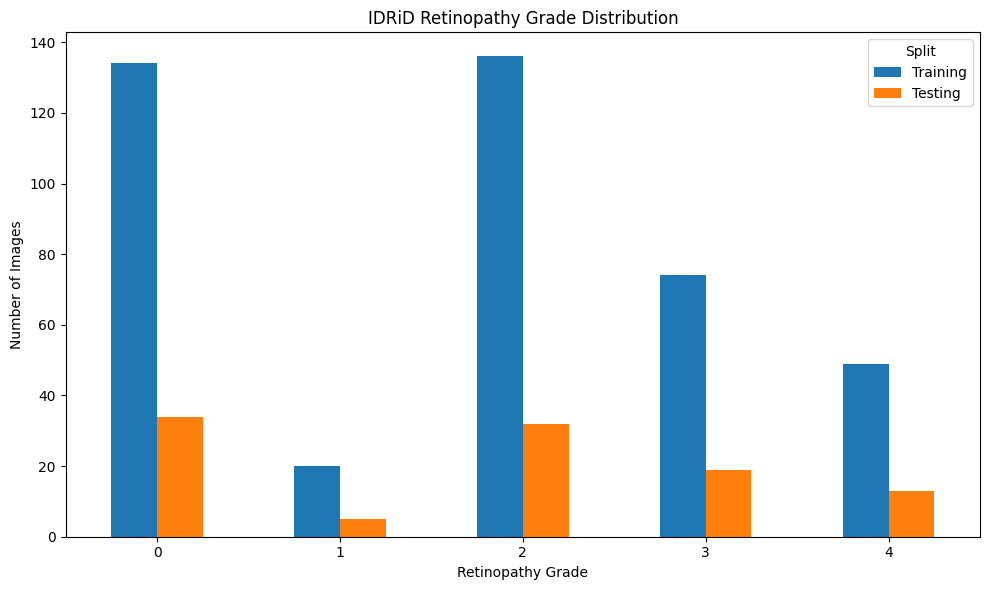

In [20]:
# Cell 20: Plot class distribution

plt.figure(figsize=(10, 6))

plot_df = class_distribution[["Training", "Testing"]]

plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("IDRiD Retinopathy Grade Distribution")
plt.xlabel("Retinopathy Grade")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Split")
plt.tight_layout()

plt.savefig(
    EDA_DIR / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Cell 21 — Random sample visualization

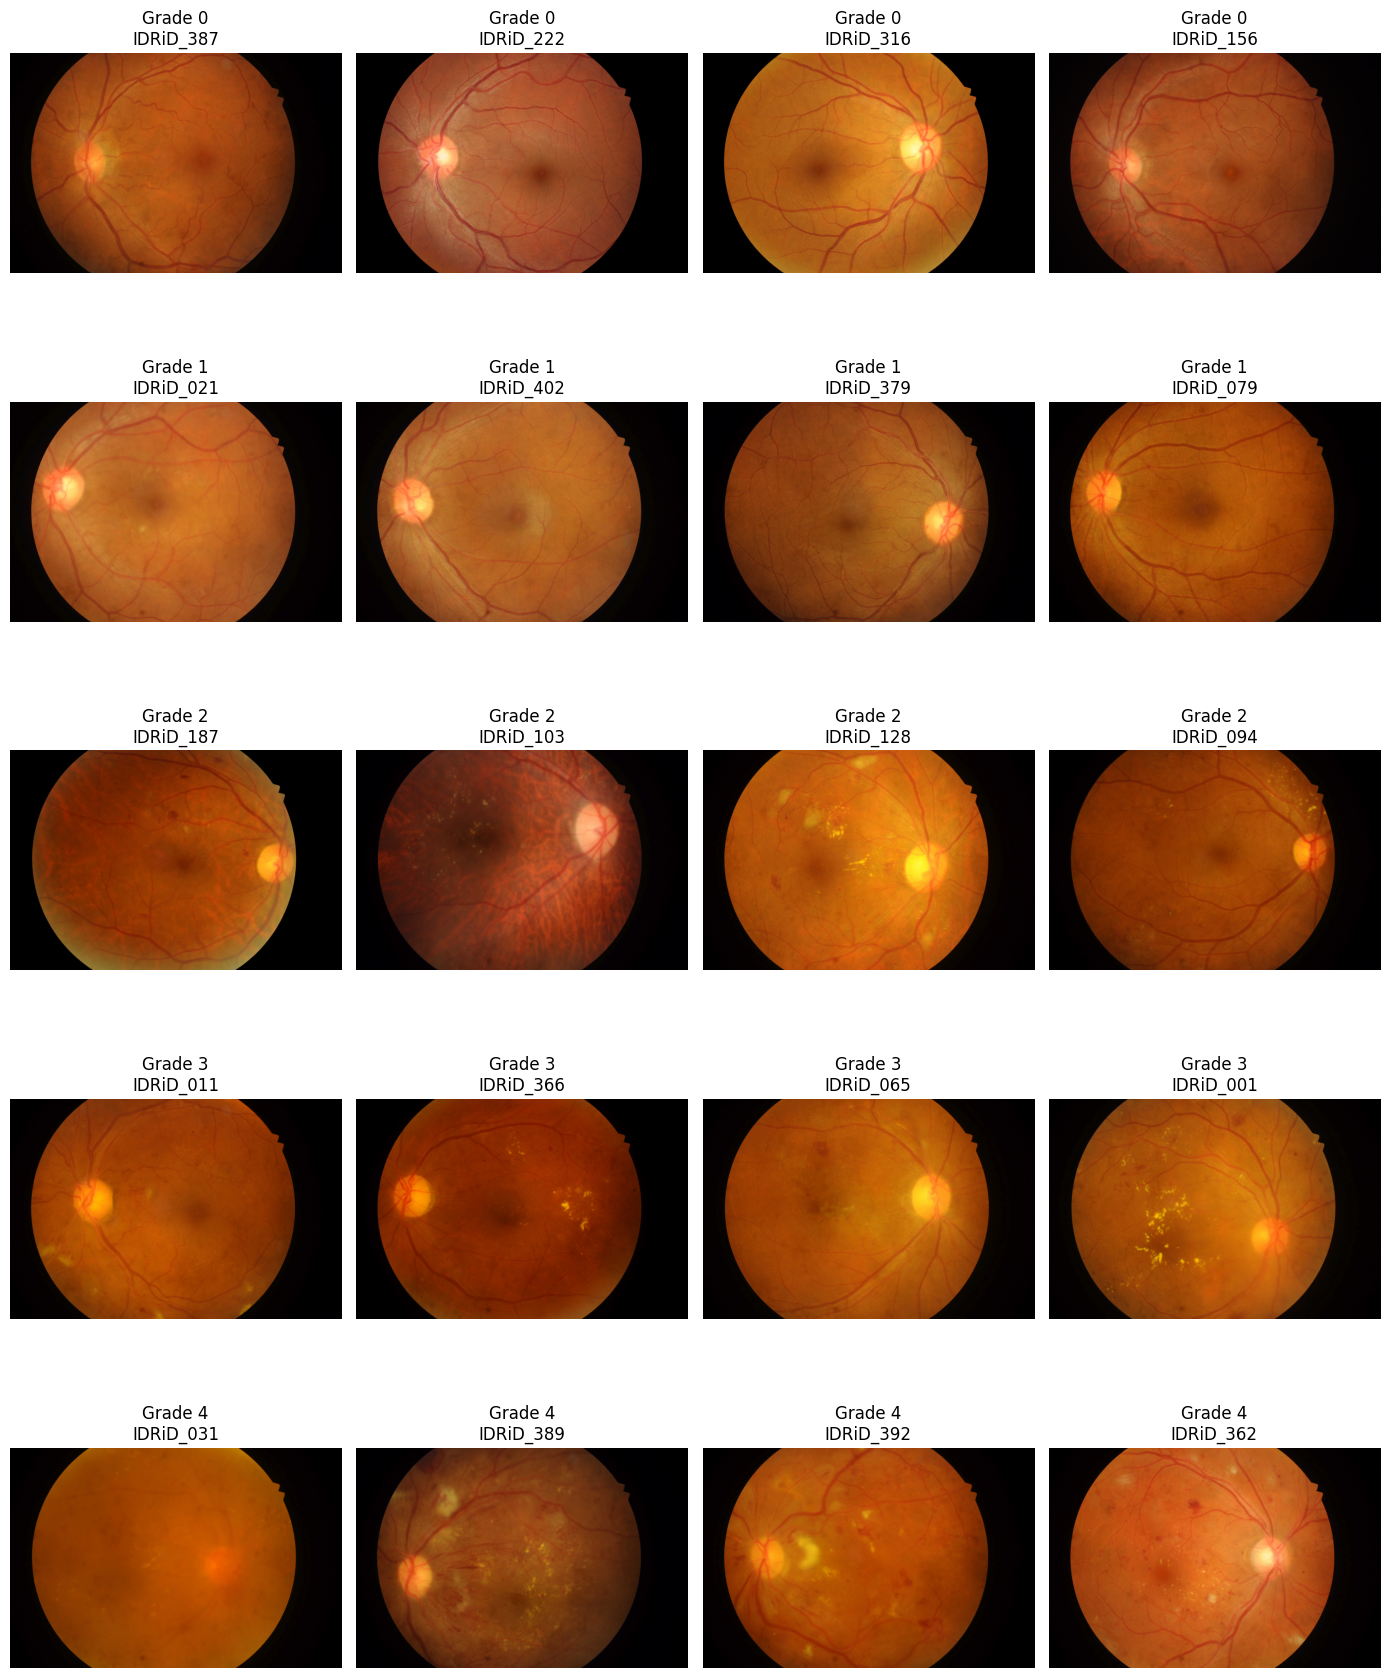

In [21]:
# Cell 21: Display random images from each class

fig, axes = plt.subplots(
    5, 4,
    figsize=(14, 18)
)

for class_id in range(5):

    class_rows = train_df[
        train_df["Retinopathy grade"] == class_id
    ]

    samples = class_rows.sample(
        min(4, len(class_rows)),
        random_state=SEED
    )

    for col, (_, row) in enumerate(samples.iterrows()):

        img = Image.open(row["image_path"]).convert("RGB")

        axes[class_id, col].imshow(img)
        axes[class_id, col].set_title(
            f"Grade {class_id}\n{row['Image name']}"
        )
        axes[class_id, col].axis("off")

    # Hide unused axes
    for col in range(len(samples), 4):
        axes[class_id, col].axis("off")


plt.tight_layout()

plt.savefig(
    EDA_DIR / "class_sample_grid.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Cell 22 — Image dimension plots

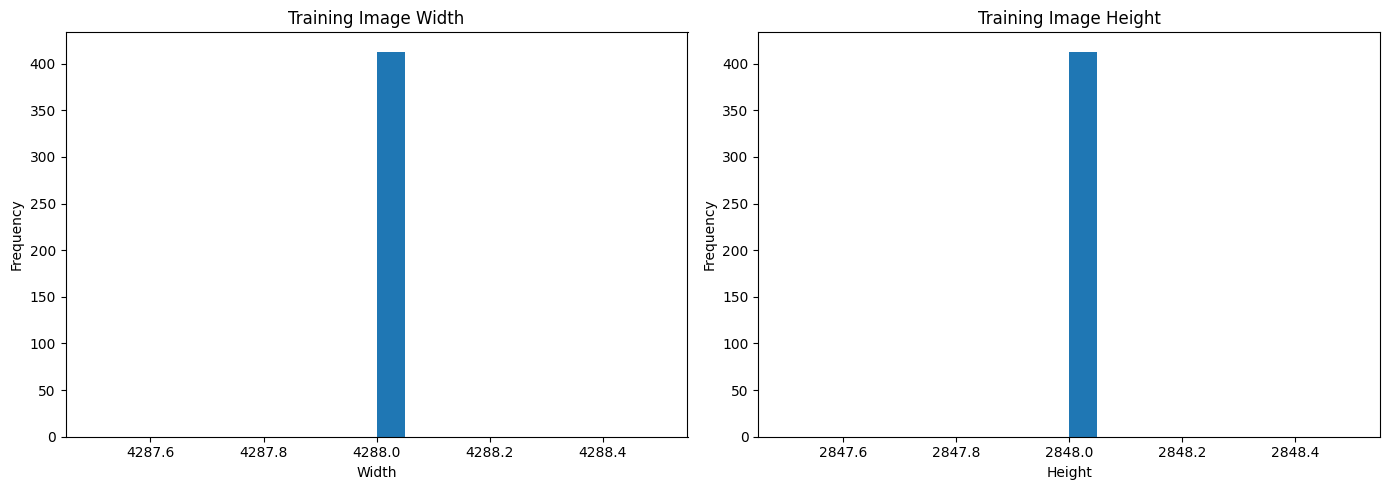

In [22]:
# Cell 22: Image dimension analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    train_image_meta["width"],
    bins=20
)
axes[0].set_title("Training Image Width")
axes[0].set_xlabel("Width")
axes[0].set_ylabel("Frequency")

axes[1].hist(
    train_image_meta["height"],
    bins=20
)
axes[1].set_title("Training Image Height")
axes[1].set_xlabel("Height")
axes[1].set_ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    EDA_DIR / "image_dimensions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Cell 23 — Brightness and contrast analysis

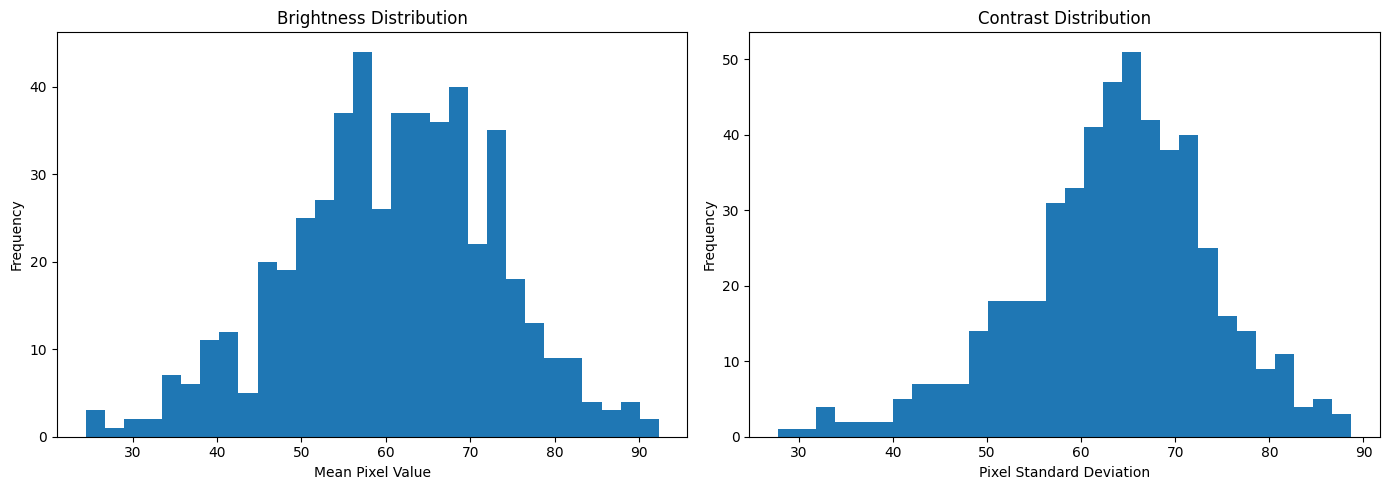

In [23]:
# Cell 23: Brightness and contrast analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    image_meta["brightness"].dropna(),
    bins=30
)

axes[0].set_title("Brightness Distribution")
axes[0].set_xlabel("Mean Pixel Value")
axes[0].set_ylabel("Frequency")

axes[1].hist(
    image_meta["contrast"].dropna(),
    bins=30
)

axes[1].set_title("Contrast Distribution")
axes[1].set_xlabel("Pixel Standard Deviation")
axes[1].set_ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    EDA_DIR / "brightness_contrast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Cell 24 — RGB channel statistics

In [24]:
# Cell 24: RGB statistics

def calculate_rgb_statistics(paths):
    records = []

    for path in paths:
        try:
            img = Image.open(path).convert("RGB")
            arr = np.asarray(img).astype(np.float32)

            records.append({
                "image_name": path.stem,
                "R_mean": arr[:, :, 0].mean(),
                "G_mean": arr[:, :, 1].mean(),
                "B_mean": arr[:, :, 2].mean(),
                "R_std": arr[:, :, 0].std(),
                "G_std": arr[:, :, 1].std(),
                "B_std": arr[:, :, 2].std(),
            })

        except Exception:
            pass

    return pd.DataFrame(records)


rgb_stats = calculate_rgb_statistics(train_files)

print(rgb_stats.describe())

           R_mean      G_mean      B_mean       R_std       G_std       B_std
count  413.000000  413.000000  413.000000  413.000000  413.000000  413.000000
mean   110.815140   53.792816   17.968679   75.804337   39.337639   14.338941
std     19.452757   13.229068   13.131392   11.570531    8.803739    9.732424
min     44.298714   17.342108    0.632058   37.262733   13.237130    1.028351
25%     99.821381   46.054379    7.122679   69.411484   33.944077    6.341880
50%    112.494553   54.414055   14.920614   76.327187   40.121521   11.669372
75%    123.442192   63.181587   27.526846   83.457962   45.439583   21.356651
max    153.155136   88.918976   65.111671  104.827347   65.106453   48.259155


### Cell 25 — Check exact duplicate files

In [25]:
# Cell 25: Exact duplicate detection using MD5

def file_md5(path, chunk_size=1024 * 1024):
    md5 = hashlib.md5()

    with open(path, "rb") as f:
        while chunk := f.read(chunk_size):
            md5.update(chunk)

    return md5.hexdigest()


all_image_files = train_files + test_files

hash_records = []

for path in all_image_files:
    hash_records.append({
        "image_name": path.stem,
        "path": str(path),
        "md5": file_md5(path)
    })

hash_df = pd.DataFrame(hash_records)

duplicates = hash_df[
    hash_df.duplicated(
        subset=["md5"],
        keep=False
    )
].sort_values("md5")

print("Exact duplicate files:", duplicates.shape[0])

if len(duplicates) > 0:
    print(duplicates)
else:
    print("No exact duplicate files found")

Exact duplicate files: 12
    image_name                                               path  \
117  IDRiD_118  B. Disease Grading\1. Original Images\a. Train...   
476  IDRiD_064  B. Disease Grading\1. Original Images\b. Testi...   
20   IDRiD_021  B. Disease Grading\1. Original Images\a. Train...   
390  IDRiD_391  B. Disease Grading\1. Original Images\a. Train...   
78   IDRiD_079  B. Disease Grading\1. Original Images\a. Train...   
278  IDRiD_279  B. Disease Grading\1. Original Images\a. Train...   
27   IDRiD_028  B. Disease Grading\1. Original Images\a. Train...   
326  IDRiD_327  B. Disease Grading\1. Original Images\a. Train...   
72   IDRiD_073  B. Disease Grading\1. Original Images\a. Train...   
374  IDRiD_375  B. Disease Grading\1. Original Images\a. Train...   
44   IDRiD_045  B. Disease Grading\1. Original Images\a. Train...   
332  IDRiD_333  B. Disease Grading\1. Original Images\a. Train...   

                                  md5  
117  2f72ef33ec56843d7425e8c599d73ab

### Cell 26 — Near-duplicate check

This can take a little time, but your dataset is small.

In [26]:
# Cell 26: Perceptual hash / near duplicate analysis

phash_records = []

for path in all_image_files:
    try:
        img = Image.open(path).convert("RGB")
        phash = str(imagehash.phash(img))

        phash_records.append({
            "image_name": path.stem,
            "path": str(path),
            "phash": phash
        })

    except Exception:
        pass


phash_df = pd.DataFrame(phash_records)

duplicate_phashes = phash_df[
    phash_df.duplicated(
        subset=["phash"],
        keep=False
    )
].sort_values("phash")

print(
    "Exact perceptual-hash matches:",
    len(duplicate_phashes)
)

if len(duplicate_phashes) > 0:
    print(duplicate_phashes)
else:
    print("No identical perceptual hashes found")

Exact perceptual-hash matches: 21
    image_name                                               path  \
374  IDRiD_375  B. Disease Grading\1. Original Images\a. Train...   
72   IDRiD_073  B. Disease Grading\1. Original Images\a. Train...   
459  IDRiD_047  B. Disease Grading\1. Original Images\b. Testi...   
42   IDRiD_043  B. Disease Grading\1. Original Images\a. Train...   
78   IDRiD_079  B. Disease Grading\1. Original Images\a. Train...   
278  IDRiD_279  B. Disease Grading\1. Original Images\a. Train...   
44   IDRiD_045  B. Disease Grading\1. Original Images\a. Train...   
332  IDRiD_333  B. Disease Grading\1. Original Images\a. Train...   
407  IDRiD_408  B. Disease Grading\1. Original Images\a. Train...   
51   IDRiD_052  B. Disease Grading\1. Original Images\a. Train...   
359  IDRiD_360  B. Disease Grading\1. Original Images\a. Train...   
19   IDRiD_020  B. Disease Grading\1. Original Images\a. Train...   
79   IDRiD_080  B. Disease Grading\1. Original Images\a. Train...   


### Cell 27 — Stratified train/validation split

In [27]:
# Cell 27: Create train/validation split

train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["Retinopathy grade"]
)

train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)
test_split_df = test_df.reset_index(drop=True)

print("Training split :", len(train_split_df))
print("Validation split:", len(val_split_df))
print("Official test  :", len(test_split_df))

print("\nTraining class distribution:")
print(train_split_df["Retinopathy grade"].value_counts().sort_index())

print("\nValidation class distribution:")
print(val_split_df["Retinopathy grade"].value_counts().sort_index())

Training split : 330
Validation split: 83
Official test  : 103

Training class distribution:
Retinopathy grade
0    107
1     16
2    109
3     59
4     39
Name: count, dtype: int64

Validation class distribution:
Retinopathy grade
0    27
1     4
2    27
3    15
4    10
Name: count, dtype: int64


### Cell 28 — Verify split integrity

In [29]:
# Cell 28: Correct split-overlap validation
# Image names may repeat between the official training and testing folders,
# so use the FULL IMAGE PATH to check actual overlap.

train_paths = set(
    Path(p).resolve()
    for p in train_split_df["image_path"]
)

val_paths = set(
    Path(p).resolve()
    for p in val_split_df["image_path"]
)

test_paths = set(
    Path(p).resolve()
    for p in test_split_df["image_path"]
)

print("Train ∩ Validation:", len(train_paths & val_paths))
print("Train ∩ Test       :", len(train_paths & test_paths))
print("Validation ∩ Test  :", len(val_paths & test_paths))

assert len(train_paths & val_paths) == 0, \
    "Actual image-path overlap found between train and validation"

assert len(train_paths & test_paths) == 0, \
    "Actual image-path overlap found between train and test"

assert len(val_paths & test_paths) == 0, \
    "Actual image-path overlap found between validation and test"

print("\n No actual image overlap between splits")

Train ∩ Validation: 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

 No actual image overlap between splits


### Cell 29 — Calculate class weights ONLY from training split

In [30]:
# Cell 29: Class weights

classes = np.array([0, 1, 2, 3, 4])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_split_df["Retinopathy grade"].values
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Class weights:")

for class_id, weight in zip(classes, class_weights):
    print(
        f"Grade {class_id}: {weight:.4f}"
    )

Class weights:
Grade 0: 0.6168
Grade 1: 4.1250
Grade 2: 0.6055
Grade 3: 1.1186
Grade 4: 1.6923


### Cell 30 — Define preprocessing and augmentation

In [31]:
# Cell 30: Image preprocessing configurations

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def get_train_transform(image_size=224):
    return transforms.Compose([
        transforms.Resize(
            (image_size, image_size)
        ),

        transforms.RandomHorizontalFlip(
            p=0.5
        ),

        transforms.RandomRotation(
            degrees=10
        ),

        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.02
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        )
    ])


def get_eval_transform(image_size=224):
    return transforms.Compose([
        transforms.Resize(
            (image_size, image_size)
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        )
    ])


train_transform_224 = get_train_transform(224)
val_transform_224 = get_eval_transform(224)

train_transform_512 = get_train_transform(512)
val_transform_512 = get_eval_transform(512)

print("224×224 and 512×512 preprocessing pipelines created")

224×224 and 512×512 preprocessing pipelines created


### Cell 31 — Create reusable IDRiD Dataset

In [32]:
# Cell 31: Reusable PyTorch Dataset

class IDRiDDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
        return_name=False
    ):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform
        self.return_name = return_name

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = row["image_path"]
        label = int(row["Retinopathy grade"])

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        if self.return_name:
            return image, label, row["Image name"]

        return image, label


print("IDRiDDataset class created")

IDRiDDataset class created


### Cell 32 — Create 224 datasets

In [33]:
# Cell 32: Create 224×224 datasets

train_dataset_224 = IDRiDDataset(
    train_split_df,
    transform=train_transform_224,
    return_name=True
)

val_dataset_224 = IDRiDDataset(
    val_split_df,
    transform=val_transform_224,
    return_name=True
)

test_dataset_224 = IDRiDDataset(
    test_split_df,
    transform=val_transform_224,
    return_name=True
)

print("Train:", len(train_dataset_224))
print("Val  :", len(val_dataset_224))
print("Test :", len(test_dataset_224))

Train: 330
Val  : 83
Test : 103


### Cell 33 — Test DataLoader

In [35]:
# Cell 33: Test 224 DataLoader - Windows/Jupyter safe

BATCH_SIZE = 16

# For Windows + Jupyter, start with num_workers=0
NUM_WORKERS = 0

train_loader_224 = DataLoader(
    train_dataset_224,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader_224 = DataLoader(
    val_dataset_224,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader_224 = DataLoader(
    test_dataset_224,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

images, labels, names = next(iter(train_loader_224))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First names:", names[:5])

assert images.shape[1:] == (3, 224, 224)

print("\n 224 DataLoader working")

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
First names: ('IDRiD_003', 'IDRiD_273', 'IDRiD_310', 'IDRiD_399', 'IDRiD_148')

 224 DataLoader working


### Cell 34 — Test 512 preprocessing

In [36]:
# Cell 34: Test 512×512 preprocessing

train_dataset_512 = IDRiDDataset(
    train_split_df,
    transform=train_transform_512,
    return_name=True
)

val_dataset_512 = IDRiDDataset(
    val_split_df,
    transform=val_transform_512,
    return_name=True
)

test_dataset_512 = IDRiDDataset(
    test_split_df,
    transform=val_transform_512,
    return_name=True
)

sample_image, sample_label, sample_name = train_dataset_512[0]

print("Image:", sample_image.shape)
print("Label:", sample_label)
print("Name :", sample_name)

assert sample_image.shape == (3, 512, 512)

print("512×512 preprocessing working")

Image: torch.Size([3, 512, 512])
Label: 1
Name : IDRiD_402
512×512 preprocessing working


### Cell 35 — Visualize transformed images

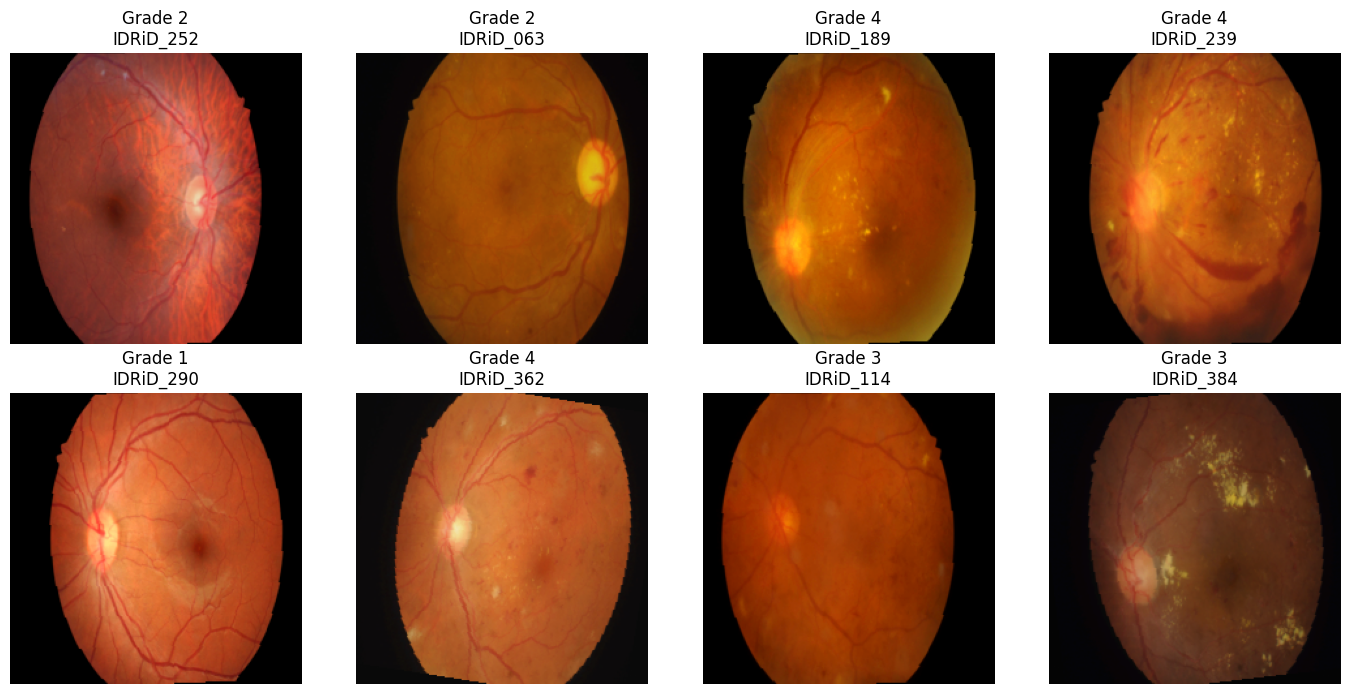

In [37]:
# Cell 35: Visualize augmentation/preprocessing

def denormalize(image_tensor):
    image = image_tensor.clone()

    mean = torch.tensor(
        IMAGENET_MEAN
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD
    ).view(3, 1, 1)

    image = image * std + mean
    image = torch.clamp(image, 0, 1)

    return image


fig, axes = plt.subplots(
    2, 4,
    figsize=(14, 7)
)

for i in range(8):

    image, label, name = train_dataset_224[
        random.randint(0, len(train_dataset_224) - 1)
    ]

    image = denormalize(image)
    image = image.permute(1, 2, 0).numpy()

    ax = axes[i // 4, i % 4]

    ax.imshow(image)
    ax.set_title(
        f"Grade {label}\n{name}"
    )
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    EDA_DIR / "preprocessed_samples.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

### Cell 36 — Save metadata

In [38]:
# Cell 36: Save cleaned metadata

train_split_df.to_csv(
    METADATA_DIR / "train.csv",
    index=False
)

val_split_df.to_csv(
    METADATA_DIR / "val.csv",
    index=False
)

test_split_df.to_csv(
    METADATA_DIR / "test.csv",
    index=False
)

class_distribution.to_csv(
    METADATA_DIR / "class_distribution.csv"
)

image_meta.to_csv(
    METADATA_DIR / "image_quality_metadata.csv",
    index=False
)

print("Metadata saved")

Metadata saved


### Cell 37 — Save preprocessing configuration

In [39]:
# Cell 37: Save preprocessing configuration

preprocessing_config = {
    "seed": SEED,
    "image_sizes": [224, 512],
    "normalization": {
        "mean": IMAGENET_MEAN,
        "std": IMAGENET_STD
    },
    "augmentation": {
        "horizontal_flip": 0.5,
        "rotation_degrees": 10,
        "brightness": 0.15,
        "contrast": 0.15,
        "saturation": 0.10,
        "hue": 0.02
    },
    "validation_ratio": 0.20,
    "stratified": True,
    "random_state": SEED,
    "num_classes": 5,
    "classes": {
        "0": "No DR",
        "1": "Mild",
        "2": "Moderate",
        "3": "Severe",
        "4": "Proliferative DR"
    }
}

with open(
    METADATA_DIR / "preprocessing_config.json",
    "w"
) as f:
    json.dump(
        preprocessing_config,
        f,
        indent=4
    )

print("Configuration saved")

Configuration saved


### Cell 38 — Save Stage 1 summary

In [40]:
# Cell 38: Generate Stage 1 summary

summary = {
    "training_images": int(len(train_df)),
    "validation_images": int(len(val_split_df)),
    "official_test_images": int(len(test_split_df)),
    "total_dataset_images": int(
        len(train_df) + len(test_split_df)
    ),
    "num_classes": 5,
    "classes": {
        "0": "No DR",
        "1": "Mild",
        "2": "Moderate",
        "3": "Severe",
        "4": "Proliferative DR"
    },
    "image_resolution_original": "4288x2848",
    "preprocessing_sizes": [224, 512],
    "class_imbalance_ratio": float(imbalance_ratio),
    "seed": SEED,
    "official_test_preserved": True
}

with open(
    METADATA_DIR / "dataset_summary.json",
    "w"
) as f:
    json.dump(
        summary,
        f,
        indent=4
    )

print(json.dumps(summary, indent=4))

{
    "training_images": 413,
    "validation_images": 83,
    "official_test_images": 103,
    "total_dataset_images": 516,
    "num_classes": 5,
    "classes": {
        "0": "No DR",
        "1": "Mild",
        "2": "Moderate",
        "3": "Severe",
        "4": "Proliferative DR"
    },
    "image_resolution_original": "4288x2848",
    "preprocessing_sizes": [
        224,
        512
    ],
    "class_imbalance_ratio": 6.8,
    "seed": 42,
    "official_test_preserved": true
}


### Cell 39 — Final Stage 1 validation

In [ ]:
# Cell 39: Final Stage 1 validation

print("=" * 70)
print("STAGE 1 FINAL VALIDATION")
print("=" * 70)

checks = {
    "Training metadata": METADATA_DIR.joinpath("train.csv").exists(),
    "Validation metadata": METADATA_DIR.joinpath("val.csv").exists(),
    "Test metadata": METADATA_DIR.joinpath("test.csv").exists(),
    "Class distribution": METADATA_DIR.joinpath(
        "class_distribution.csv"
    ).exists(),
    "Preprocessing config": METADATA_DIR.joinpath(
        "preprocessing_config.json"
    ).exists(),
    "EDA class plot": EDA_DIR.joinpath(
        "class_distribution.png"
    ).exists(),
    "Sample grid": EDA_DIR.joinpath(
        "class_sample_grid.png"
    ).exists(),
    "Image dimension plot": EDA_DIR.joinpath(
        "image_dimensions.png"
    ).exists(),
    "Brightness/contrast plot": EDA_DIR.joinpath(
        "brightness_contrast.png"
    ).exists(),
}

for name, status in checks.items():
    print(f"{'' if status else 'no'} {name}")

print("\n" + "=" * 70)
print("FINAL DATA SPLITS")
print("=" * 70)

print("Train      :", len(train_split_df))
print("Validation :", len(val_split_df))
print("Test       :", len(test_split_df))

print("\n" + "=" * 70)
print("STAGE 1 COMPLETE")
print("=" * 70)

print("""
Next stage:
    Local/Centralized ResNet50 training

Do NOT start FedAvg or Differential Privacy until
the local baseline is established.
""")

STAGE 1 FINAL VALIDATION
 Training metadata
 Validation metadata
 Test metadata
 Class distribution
 Preprocessing config
 EDA class plot
 Sample grid
 Image dimension plot
 Brightness/contrast plot

FINAL DATA SPLITS
Train      : 330
Validation : 83
Test       : 103

STAGE 1 COMPLETE

Next stage:
    Local/Centralized ResNet50 training

Do NOT start FedAvg or Differential Privacy until
the local baseline is established.



: 

## What you should get after these cells

Your output should contain:

```text
./processed_idrid/
│
├── eda/
│   ├── class_distribution.png
│   ├── class_sample_grid.png
│   ├── image_dimensions.png
│   ├── brightness_contrast.png
│   └── preprocessed_samples.png
│
├── metadata/
│   ├── train.csv
│   ├── val.csv
│   ├── test.csv
│   ├── class_distribution.csv
│   ├── image_quality_metadata.csv
│   ├── preprocessing_config.json
│   └── dataset_summary.json
│
└── reports/
```

One important point: **do not conclude yet that 224 or 512 is better**. Stage 1 prepares both. The actual choice should be made using the **validation performance in Stage 2**, without touching the official 103-image test set.